# 03 CNN+BiLSTM+Attention 情感模型训练

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
import math
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/Emotion-perception-driven-speech-recognition-system


In [2]:
import sys
import time
import copy
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset, Subset
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config, EMOTION_LABELS
from utils.losses import FocalLoss
from utils.split_utils import speaker_group_split, validate_subset_groups, infer_subset_from_path
from preprocessing.feature_extract import EmotionDataset, AudioAugmentation
from models.emotion_cnn_bilstm import EmotionRecognizer

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')


设备: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. 准备数据

In [3]:
from preprocessing.feature_extract import EmotionDataset, AudioAugmentation

"""论文演示目的：
构建用于训练的 Dataset 列表，并展示"跨数据集拼接训练"的做法。

这里的 EmotionDataset 读取的是 preprocessing/feature_extract.py 输出的 .npy 特征文件：
    data/features/<subset>/{mel,mfcc}/<label>/*.npy

注意：该 Dataset 的一个隐含约束是 mel/ 目录下第一层必须是情感标签目录名。
"""

features_root = cfg['paths']['features']
feature_type = 'mel'

# 训练阶段使用数据增强（SpecAugment + 噪声）；验证/测试不增强
train_transform = AudioAugmentation(
    time_mask_max=20,
    freq_mask_max=10,
    noise_std=0.01,
)

training_cfg = cfg.get('training', {})
default_main_subsets = ('ravdess', 'casia', 'esd', 'emodb', 'iemocap')
default_auxiliary_subsets = ('tess',)
configured_main_subsets = tuple(
    str(subset).strip().lower()
    for subset in training_cfg.get('main_subsets', default_main_subsets)
)
configured_auxiliary_subsets = tuple(
    str(subset).strip().lower()
    for subset in training_cfg.get('auxiliary_subsets', default_auxiliary_subsets)
)

if not configured_main_subsets:
    raise ValueError('training.main_subsets 不能为空')
if set(configured_main_subsets) & set(configured_auxiliary_subsets):
    raise ValueError(
        f'main_subsets 与 auxiliary_subsets 不能重叠: {set(configured_main_subsets) & set(configured_auxiliary_subsets)}'
    )

train_datasets = []
valtest_datasets = []
loaded_main_subsets = []
missing_main_subsets = []

# 基线 notebook 仅对主评测子集执行严格三划分；辅助子集不参与训练切分
for subset in configured_main_subsets:
    subset_features = os.path.join(features_root, subset)
    if not os.path.isdir(subset_features):
        missing_main_subsets.append(subset)
        print(f'[跳过] 特征目录不存在: {subset_features}')
        continue

    train_datasets.append(
        EmotionDataset(subset_features, feature_type=feature_type, transform=train_transform)
    )
    valtest_datasets.append(
        EmotionDataset(subset_features, feature_type=feature_type, transform=None)
    )
    loaded_main_subsets.append(subset)

main_subsets = tuple(loaded_main_subsets)
auxiliary_subsets = tuple(configured_auxiliary_subsets)

if not main_subsets:
    raise RuntimeError('没有成功加载任何主评测子集，请先完成特征提取并检查 training.main_subsets 对应目录。')

print(f'主评测子集: {main_subsets}')
if auxiliary_subsets:
    print(f'辅助子集（不参与基线三划分训练）: {auxiliary_subsets}')
if missing_main_subsets:
    print(f'缺失的主评测子集目录: {tuple(missing_main_subsets)}')
print(f'训练子集数量: {len(train_datasets)} | 验证/测试子集数量: {len(valtest_datasets)}')


EmotionDataset: 加载 1440 个样本 (feature_type=mel)
EmotionDataset: 加载 1440 个样本 (feature_type=mel)
EmotionDataset: 加载 1200 个样本 (feature_type=mel)
EmotionDataset: 加载 1200 个样本 (feature_type=mel)
EmotionDataset: 加载 34997 个样本 (feature_type=mel)
EmotionDataset: 加载 34997 个样本 (feature_type=mel)
EmotionDataset: 加载 535 个样本 (feature_type=mel)
EmotionDataset: 加载 535 个样本 (feature_type=mel)
EmotionDataset: 加载 7415 个样本 (feature_type=mel)
EmotionDataset: 加载 7415 个样本 (feature_type=mel)
主评测子集: ('ravdess', 'casia', 'esd', 'emodb', 'iemocap')
辅助子集（不参与基线三划分训练）: ('tess',)
训练子集数量: 5 | 验证/测试子集数量: 5


In [4]:
# 将多个主评测子集合并，并构建 train/val/test 划分与 DataLoader
full_train = ConcatDataset(train_datasets)       # 训练用（含增强）
full_plain = ConcatDataset(valtest_datasets)     # 验证/测试用（不增强）

if len(full_train) == 0:
    raise RuntimeError('没有可用训练数据，请先完成特征提取并检查 data/features/<subset>/ 目录。')
if len(full_train) != len(full_plain):
    raise RuntimeError('增强集与非增强集样本数不一致，请检查数据准备流程。')

sample_paths = []
for dataset in full_plain.datasets:
    sample_paths.extend([path for path, _ in dataset.samples])

if len(sample_paths) != len(full_plain):
    raise RuntimeError(
        f'样本路径数量与数据集长度不一致: paths={len(sample_paths)} dataset={len(full_plain)}'
    )

sample_subsets = np.asarray([infer_subset_from_path(path) for path in sample_paths], dtype=object)
train_ratio = float(cfg['training']['train_ratio'])
val_ratio = float(cfg['training']['val_ratio'])
test_ratio = float(cfg['training']['test_ratio'])
seed = int(cfg['training']['seed'])
protocol_version = int(cfg['training'].get('protocol_version', 2))

split_audit = validate_subset_groups(
    sample_paths,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    subsets=main_subsets,
)

train_indices, val_indices, test_indices, split_meta = speaker_group_split(
    sample_paths,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    seed=seed,
    include_subsets=main_subsets,
)

train_set = Subset(full_train, train_indices)
val_set = Subset(full_plain, val_indices)
test_set = Subset(full_plain, test_indices)

bs = cfg['training']['batch_size']
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

val_loaders_by_subset = {}
test_loaders_by_subset = {}
val_subset_eval_counts = {}
test_subset_eval_counts = {}
for subset in main_subsets:
    val_subset_indices = [idx for idx in val_indices if sample_subsets[idx] == subset]
    test_subset_indices = [idx for idx in test_indices if sample_subsets[idx] == subset]
    if val_subset_indices:
        val_loaders_by_subset[subset] = DataLoader(
            Subset(full_plain, val_subset_indices),
            batch_size=bs,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )
        val_subset_eval_counts[subset] = int(len(val_subset_indices))
    if test_subset_indices:
        test_loaders_by_subset[subset] = DataLoader(
            Subset(full_plain, test_subset_indices),
            batch_size=bs,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )
        test_subset_eval_counts[subset] = int(len(test_subset_indices))

split_meta.update({
    'protocol_version': int(protocol_version),
    'seed': int(seed),
    'main_subsets': list(main_subsets),
    'auxiliary_subsets': list(auxiliary_subsets),
    'dataset_audit': split_audit['subset_audit'],
    'dataset_normalization_warnings': split_audit.get('normalization_warnings', []),
    'val_subset_eval_counts': val_subset_eval_counts,
    'test_subset_eval_counts': test_subset_eval_counts,
})

print('说话人分组审计:')
print(split_audit['subset_audit'])
print(split_meta)
print('验证/测试子集评估样本数:')
print({'val': val_subset_eval_counts, 'test': test_subset_eval_counts})
print(f'训练: {len(train_set)}, 验证: {len(val_set)}, 测试: {len(test_set)}')


说话人分组审计:
{'ravdess': {'num_groups': 24, 'num_samples': 1440, 'speaker_ids': ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24'], 'can_three_way_split': True, 'required_splits': 3}, 'casia': {'num_groups': 4, 'num_samples': 1200, 'speaker_ids': ['ZhaoZuoxiang', 'liuchanhg', 'wangzhe', 'zhaoquanyin'], 'can_three_way_split': True, 'required_splits': 3}, 'esd': {'num_groups': 20, 'num_samples': 34997, 'speaker_ids': ['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020'], 'can_three_way_split': True, 'required_splits': 3}, 'emodb': {'num_groups': 10, 'num_samples': 535, 'speaker_ids': ['03', '08', '09', '10', '11', '12', '13', '14', '15', '16'], 'can_three_way_split': True, 'required_splits': 3}, 'iemocap': {'num_groups': 10, 'num_samples': 7415, 'speaker_ids': ['Ses01F', 'Ses01M', 'Ses02F', 'Se

## 2. 构建模型

In [5]:
model = EmotionRecognizer(
    num_classes=cfg['emotion']['num_classes'],
    n_mels=cfg['audio']['n_mels'],
    cnn_channels=tuple(cfg['model']['cnn_channels']),
    lstm_hidden=cfg['model']['lstm_hidden'],
    lstm_layers=cfg['model']['lstm_layers'],
    lstm_dropout=cfg['model']['dropout'],
    attn_dim=cfg['model']['attention_dim'],
    cls_hidden=cfg['model']['classifier_hidden'],
    cls_dropout=cfg['model']['classifier_dropout'],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'模型参数: {total_params:,} (可训练: {trainable_params:,})')
print(model)

模型参数: 3,037,758 (可训练: 3,037,758)
EmotionRecognizer(
  (cnn_blocks): ModuleList(
    (0): _ResidualCNNBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): _SEBlock(
        (pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=32, out_features=8, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=8, out_features=32, bias=True)
          (3): Sigmoid()
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (dropout): Dropout2d(p=0.1, inplace=False)
      (shortcut): Sequential(
        (0): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): _ResidualCNNBlock(
      (conv): Conv2d(32, 64, kernel_size

## 3. 训练

In [6]:
from sklearn.metrics import f1_score, recall_score


def evaluate_loader(model, loader, criterion, device, return_outputs=False):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for feats, labels in loader:
            feats = feats.to(device)
            labels = labels.to(device)
            logits = model(feats)
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)

            batch_size = int(labels.size(0))
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    metrics = {
        'loss': float(total_loss / total_count),
        'acc': float(total_correct / total_count),
        'macro_f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0)),
        'uar': float(recall_score(all_labels, all_preds, average='macro', zero_division=0)),
    }
    if return_outputs:
        return metrics, np.asarray(all_preds, dtype=np.int64), np.asarray(all_labels, dtype=np.int64)
    return metrics


def evaluate_subset_loaders(model, loaders_by_subset, criterion, device):
    results = {}
    for subset, loader in loaders_by_subset.items():
        metrics = evaluate_loader(model, loader, criterion, device)
        results[subset] = {
            'samples': int(len(loader.dataset)),
            'loss': float(metrics['loss']),
            'acc': float(metrics['acc']),
            'macro_f1': float(metrics['macro_f1']),
            'uar': float(metrics['uar']),
        }
    return results


def compute_subset_mean_metric(metrics_by_subset, metric_key='uar', subset_order=None):
    subset_order = list(subset_order or metrics_by_subset.keys())
    values = [float(metrics_by_subset[subset][metric_key]) for subset in subset_order if subset in metrics_by_subset]
    if not values:
        return float('nan')
    return float(np.mean(values))


label_smoothing = float(cfg['training'].get('label_smoothing', 0.1))
use_focal = bool(cfg['training'].get('focal_loss', False))
focal_gamma = float(cfg['training'].get('focal_gamma', 2.0))

num_classes = cfg['emotion']['num_classes']
class_counts = np.zeros(num_classes)
for _, label in train_set:
    class_counts[label] += 1
class_weights = 1.0 / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
class_weights_dict = {
    label: float(weight)
    for label, weight in zip(cfg['emotion']['labels'], class_weights.tolist())
}
print(f'类别样本数: {dict(zip(cfg["emotion"]["labels"], class_counts.astype(int)))}')
print(f'类别权重: {dict(zip(cfg["emotion"]["labels"], [f"{w:.3f}" for w in class_weights]))}')

if use_focal:
    criterion = FocalLoss(gamma=focal_gamma, alpha=class_weights.tolist(), label_smoothing=label_smoothing)
    criterion_name = 'focal_loss'
    criterion_config = {
        'gamma': float(focal_gamma),
        'label_smoothing': float(label_smoothing),
        'alpha': [float(value) for value in class_weights.tolist()],
        'weighted': True,
    }
    print(f'损失函数: FocalLoss (gamma={focal_gamma}, label_smoothing={label_smoothing})')
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=label_smoothing)
    criterion_name = 'cross_entropy'
    criterion_config = {
        'label_smoothing': float(label_smoothing),
        'weight': [float(value) for value in class_weights.tolist()],
        'weighted': True,
    }
    print(f'损失函数: CrossEntropyLoss (label_smoothing={label_smoothing}, weighted)')

base_lr = float(cfg['training']['learning_rate'])
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=base_lr,
    weight_decay=float(cfg['training']['weight_decay']),
)
warmup_epochs = max(0, int(cfg['training'].get('warmup_epochs', 3)))
cosine_epochs = max(1, int(cfg['training']['epochs']) - warmup_epochs)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cosine_epochs,
    eta_min=1e-6,
)
print(f'优化器: AdamW (lr={base_lr}, warmup={warmup_epochs} epochs, cosine decay)')

best_metric_name = 'subset_mean_uar'
best_metric_label = 'val_subset_mean_uar'
secondary_metric_name = 'uar'
secondary_metric_label = 'val_uar'
selection_start_epoch = 1 if warmup_epochs <= 0 else warmup_epochs
checkpoint_filename = os.path.basename(cfg['paths']['best_emotion_model'])
history_filename = 'emotion_history.npz'
summary_filename = 'emotion_summary.json'
curve_filename = 'emotion_training_curves.png'
cm_filename = 'confusion_matrix.png'
experiment_name = 'emotion_cnn_bilstm_attention'

print({
    'protocol_version': int(protocol_version),
    'seed': int(seed),
    'main_subsets': list(main_subsets),
    'auxiliary_subsets': list(auxiliary_subsets),
    'best_metric': best_metric_label,
    'secondary_metric': secondary_metric_label,
    'criterion_name': criterion_name,
    'criterion_config': criterion_config,
    'selection_start_epoch': int(selection_start_epoch),
})

epochs = int(cfg['training']['epochs'])
patience = int(cfg['training']['patience'])
best_monitor_value = float('-inf')
best_secondary_monitor_value = float('-inf')
best_val_loss_at_best = float('inf')
best_epoch = 0
best_state = None
best_selected_metrics = None
best_per_subset_val_metrics = None
wait = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_macro_f1': [],
    'val_uar': [],
    'val_subset_mean_uar': [],
}

for epoch in range(1, epochs + 1):
    t0 = time.time()

    if warmup_epochs > 0 and epoch <= warmup_epochs:
        lr = base_lr * (epoch / warmup_epochs)
        for group in optimizer.param_groups:
            group['lr'] = lr

    model.train()
    tr_loss = 0.0
    tr_correct = 0
    tr_total = 0
    for feats, labels in train_loader:
        feats = feats.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        tr_loss += loss.item() * feats.size(0)
        tr_correct += (logits.argmax(dim=1) == labels).sum().item()
        tr_total += feats.size(0)

    train_metrics = {
        'loss': float(tr_loss / tr_total),
        'acc': float(tr_correct / tr_total),
    }
    val_metrics = evaluate_loader(model, val_loader, criterion, device)
    per_subset_val_metrics = evaluate_subset_loaders(model, val_loaders_by_subset, criterion, device)
    val_metrics['subset_mean_uar'] = compute_subset_mean_metric(
        per_subset_val_metrics,
        metric_key='uar',
        subset_order=main_subsets,
    )

    if epoch > warmup_epochs:
        scheduler.step()

    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['acc'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['val_uar'].append(val_metrics['uar'])
    history['val_subset_mean_uar'].append(val_metrics['subset_mean_uar'])

    monitor_value = float(val_metrics[best_metric_name])
    secondary_monitor_value = float(val_metrics[secondary_metric_name])
    cur_lr = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0
    print(
        f'Epoch {epoch:3d}/{epochs} | '
        f'Train Loss: {train_metrics["loss"]:.4f} Acc: {train_metrics["acc"]:.4f} | '
        f'Val Loss: {val_metrics["loss"]:.4f} Acc: {val_metrics["acc"]:.4f} '
        f'Macro-F1: {val_metrics["macro_f1"]:.4f} UAR: {val_metrics["uar"]:.4f} '
        f'Subset-UAR: {val_metrics["subset_mean_uar"]:.4f} | '
        f'Monitor: {best_metric_label}={monitor_value:.4f}, {secondary_metric_label}={secondary_monitor_value:.4f} | '
        f'LR: {cur_lr:.6f} | {elapsed:.1f}s'
    )

    is_better = (
        monitor_value > best_monitor_value
        or (
            math.isclose(monitor_value, best_monitor_value, rel_tol=0.0, abs_tol=1e-6)
            and (
                secondary_monitor_value > best_secondary_monitor_value
                or (
                    math.isclose(secondary_monitor_value, best_secondary_monitor_value, rel_tol=0.0, abs_tol=1e-6)
                    and val_metrics['loss'] < best_val_loss_at_best
                )
            )
        )
    )

    if epoch >= selection_start_epoch:
        if best_state is None or is_better:
            best_monitor_value = monitor_value
            best_secondary_monitor_value = secondary_monitor_value
            best_val_loss_at_best = float(val_metrics['loss'])
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            best_selected_metrics = copy.deepcopy(val_metrics)
            best_per_subset_val_metrics = copy.deepcopy(per_subset_val_metrics)
            wait = 0
            print(f'  -> 最佳模型已按 {best_metric_label} / {secondary_metric_label} / val_loss 保存')
        else:
            wait += 1
            if wait >= patience:
                print()
                print(f'早停: 连续 {patience} 轮在 {best_metric_label} 上无改善')
                break

if best_state is None or best_selected_metrics is None:
    raise RuntimeError('训练结束但未保存任何最佳模型，请检查 warmup 和监控逻辑。')

os.makedirs(cfg['paths']['checkpoints'], exist_ok=True)
torch.save(best_state, cfg['paths']['best_emotion_model'])
np.savez(os.path.join(cfg['paths']['checkpoints'], history_filename), **history)
print()
print(f'最佳 epoch: {best_epoch}')
print(f'模型已保存至: {cfg["paths"]["best_emotion_model"]}')


类别样本数: {'happy': 7136, 'angry': 8339, 'sad': 6759, 'neutral': 7359, 'fear': 468, 'surprise': 6121}
类别权重: {'happy': '0.296', 'angry': '0.253', 'sad': '0.312', 'neutral': '0.287', 'fear': '4.508', 'surprise': '0.345'}
损失函数: CrossEntropyLoss (label_smoothing=0.05, weighted)
优化器: AdamW (lr=0.0002, warmup=3 epochs, cosine decay)
{'protocol_version': 2, 'seed': 42, 'main_subsets': ['ravdess', 'casia', 'esd', 'emodb', 'iemocap'], 'auxiliary_subsets': ['tess'], 'best_metric': 'val_subset_mean_uar', 'secondary_metric': 'val_uar', 'criterion_name': 'cross_entropy', 'criterion_config': {'label_smoothing': 0.05, 'weight': [0.2956408004107808, 0.25299109626230143, 0.31213089979750436, 0.28668198827712077, 4.507890495152418, 0.3446647200998745], 'weighted': True}, 'selection_start_epoch': 3}
Epoch   1/100 | Train Loss: 1.8959 Acc: 0.1922 | Val Loss: 1.9195 Acc: 0.2140 Macro-F1: 0.1744 UAR: 0.2739 Subset-UAR: 0.2089 | Monitor: val_subset_mean_uar=0.2089, val_uar=0.2739 | LR: 0.000067 | 19.2s
Epoch   

## 4. 训练曲线

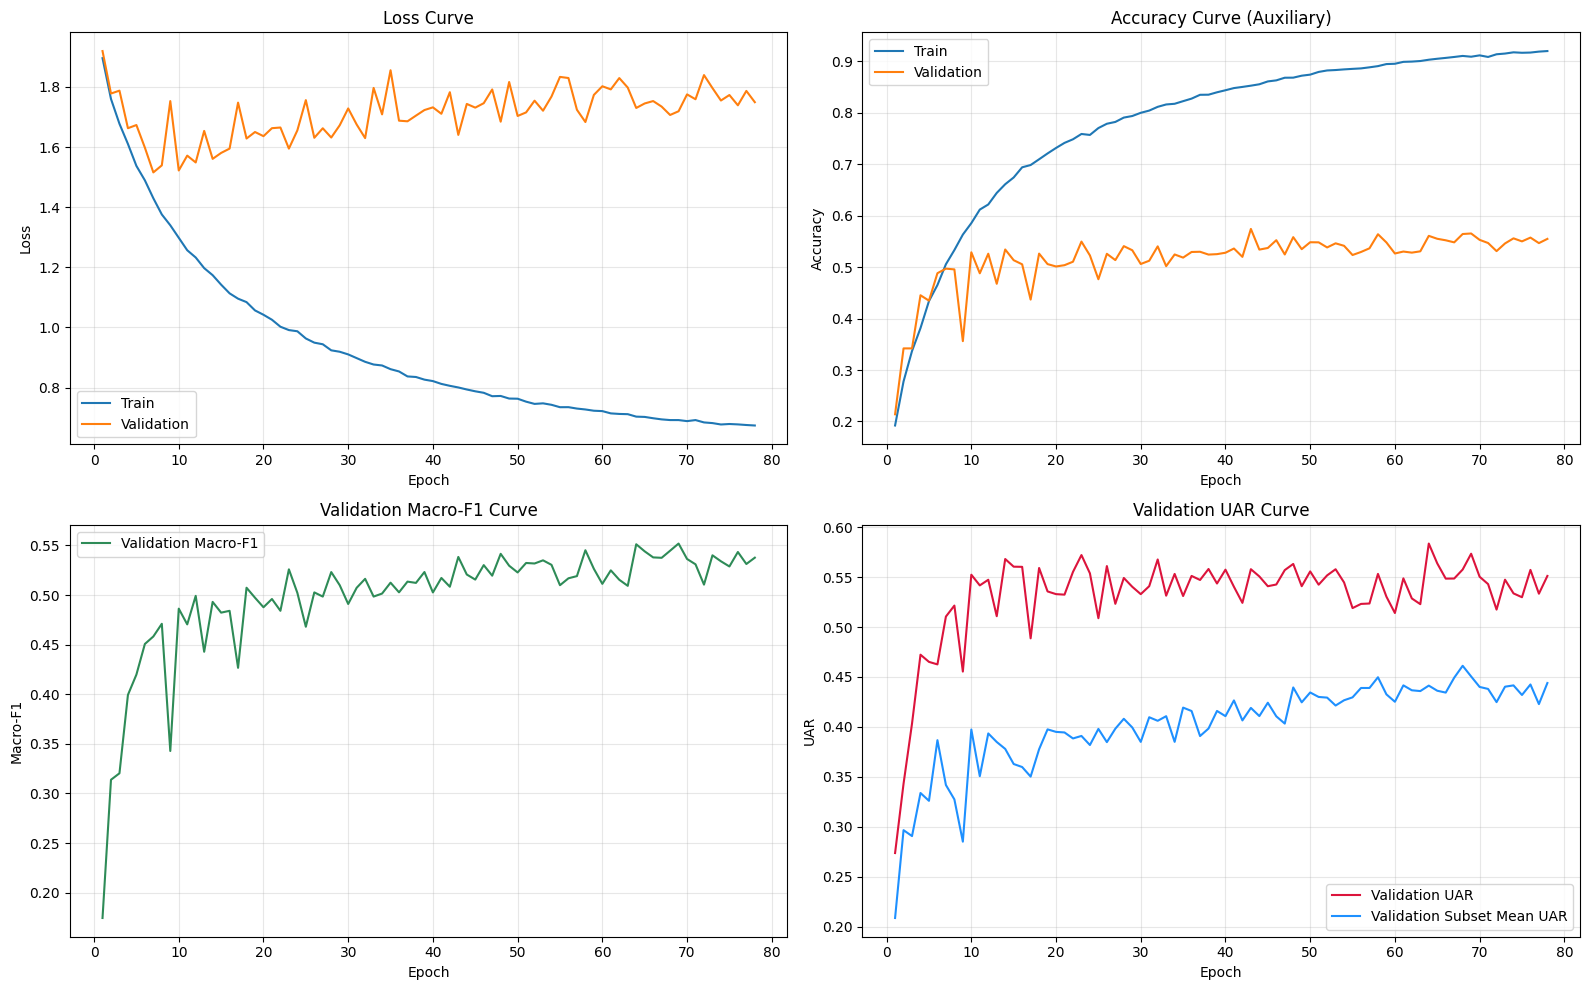

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax_loss = axes[0, 0]
ax_acc = axes[0, 1]
ax_f1 = axes[1, 0]
ax_uar = axes[1, 1]

epochs_range = range(1, len(history['val_loss']) + 1)

ax_loss.plot(epochs_range, history['train_loss'], label='Train')
ax_loss.plot(epochs_range, history['val_loss'], label='Validation')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.set_title('Loss Curve')
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

ax_acc.plot(epochs_range, history['train_acc'], label='Train')
ax_acc.plot(epochs_range, history['val_acc'], label='Validation')
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Accuracy')
ax_acc.set_title('Accuracy Curve (Auxiliary)')
ax_acc.legend()
ax_acc.grid(True, alpha=0.3)

ax_f1.plot(epochs_range, history['val_macro_f1'], label='Validation Macro-F1', color='#2E8B57')
ax_f1.set_xlabel('Epoch')
ax_f1.set_ylabel('Macro-F1')
ax_f1.set_title('Validation Macro-F1 Curve')
ax_f1.legend()
ax_f1.grid(True, alpha=0.3)

ax_uar.plot(epochs_range, history['val_uar'], label='Validation UAR', color='#DC143C')
ax_uar.plot(epochs_range, history['val_subset_mean_uar'], label='Validation Subset Mean UAR', color='#1E90FF')
ax_uar.set_xlabel('Epoch')
ax_uar.set_ylabel('UAR')
ax_uar.set_title('Validation UAR Curve')
ax_uar.legend()
ax_uar.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], curve_filename), dpi=150)
plt.show()


## 5. 测试集评估

              precision    recall  f1-score   support

       happy       0.45      0.39      0.42       947
       angry       0.62      0.72      0.67      1012
         sad       0.70      0.62      0.66       881
     neutral       0.67      0.63      0.65       933
        fear       0.34      0.53      0.42        90
    surprise       0.48      0.52      0.50       789

    accuracy                           0.58      4652
   macro avg       0.54      0.57      0.55      4652
weighted avg       0.58      0.58      0.58      4652

验证子集指标:
{'ravdess': {'samples': 120, 'loss': 1.042593002319336, 'acc': 0.6333333333333333, 'macro_f1': 0.54705910031997, 'uar': 0.5833333333333334}, 'casia': {'samples': 300, 'loss': 1.4292186482747395, 'acc': 0.4066666666666667, 'macro_f1': 0.3651645876232164, 'uar': 0.40666666666666657}, 'esd': {'samples': 3499, 'loss': 1.774805097213368, 'acc': 0.5813089454129752, 'macro_f1': 0.5041294345586741, 'uar': 0.4843759792901423}, 'emodb': {'samples': 55, 'l

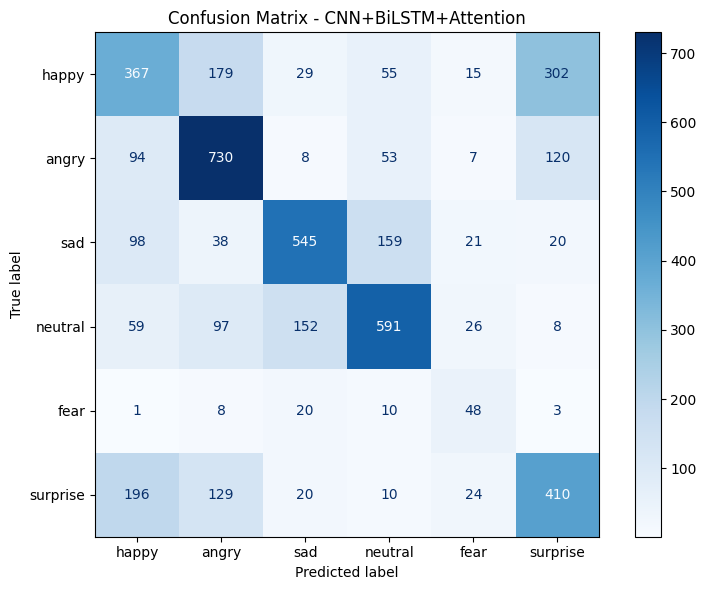

实验摘要:
{'protocol_version': 2, 'num_runs': 1, 'experiment_name': 'emotion_cnn_bilstm_attention', 'experiment_stem': 'emotion_cnn_bilstm_attention', 'variant': 'cnn_bilstm_attention', 'training_mode': 'mel_supervised', 'seed': 42, 'included_subsets': ['ravdess', 'casia', 'esd', 'emodb', 'iemocap'], 'auxiliary_subsets': ['tess'], 'split_meta': {'included_subsets': ['ravdess', 'casia', 'esd', 'emodb', 'iemocap'], 'excluded_subsets': ['tess'], 'total_samples': 45587, 'total_groups': 68, 'train_samples': 36182, 'val_samples': 4753, 'test_samples': 4652, 'train_groups': 54, 'val_groups': 7, 'test_groups': 7, 'subset_group_counts': {'ravdess': 24, 'casia': 4, 'esd': 20, 'emodb': 10, 'iemocap': 10}, 'subset_sample_counts': {'ravdess': 1440, 'casia': 1200, 'esd': 34997, 'emodb': 535, 'iemocap': 7415}, 'train_subset_group_counts': {'ravdess': 20, 'casia': 2, 'esd': 16, 'emodb': 8, 'iemocap': 8}, 'val_subset_group_counts': {'ravdess': 2, 'casia': 1, 'esd': 2, 'emodb': 1, 'iemocap': 1}, 'test_subse

In [8]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)

model.load_state_dict(best_state)
test_metrics, all_preds, all_labels_list = evaluate_loader(
    model,
    test_loader,
    criterion,
    device,
    return_outputs=True,
)
per_subset_val_metrics = best_per_subset_val_metrics if best_per_subset_val_metrics is not None else evaluate_subset_loaders(
    model,
    val_loaders_by_subset,
    criterion,
    device,
)
per_subset_test_metrics = evaluate_subset_loaders(
    model,
    test_loaders_by_subset,
    criterion,
    device,
)
val_subset_mean_uar = compute_subset_mean_metric(per_subset_val_metrics, metric_key='uar', subset_order=main_subsets)
test_subset_mean_uar = compute_subset_mean_metric(per_subset_test_metrics, metric_key='uar', subset_order=main_subsets)
label_ids = list(range(len(EMOTION_LABELS)))
weighted_f1 = float(f1_score(all_labels_list, all_preds, average='weighted', zero_division=0))
overall_test_metrics = {
    'acc': float(accuracy_score(all_labels_list, all_preds)),
    'macro_f1': float(test_metrics['macro_f1']),
    'weighted_f1': weighted_f1,
    'uar': float(test_metrics['uar']),
    'subset_mean_uar': float(test_subset_mean_uar),
    'loss': float(test_metrics['loss']),
}
per_class_recall_values = recall_score(
    all_labels_list,
    all_preds,
    labels=label_ids,
    average=None,
    zero_division=0,
)
per_class_recall = {
    label: float(score)
    for label, score in zip(EMOTION_LABELS, per_class_recall_values)
}

report_text = classification_report(
    all_labels_list,
    all_preds,
    labels=label_ids,
    target_names=EMOTION_LABELS,
    zero_division=0,
)
print(report_text)
print('验证子集指标:')
print(per_subset_val_metrics)
print(f'验证子集平均 UAR: {val_subset_mean_uar:.4f}')
print('测试集总体指标:')
print(overall_test_metrics)
print('测试子集指标:')
print(per_subset_test_metrics)
print(f'测试子集平均 UAR: {test_subset_mean_uar:.4f}')
print('逐类召回率:')
print(per_class_recall)

cm = confusion_matrix(all_labels_list, all_preds, labels=label_ids)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - CNN+BiLSTM+Attention')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], cm_filename), dpi=150)
plt.show()

summary = {
    'protocol_version': int(protocol_version),
    'num_runs': 1,
    'experiment_name': experiment_name,
    'experiment_stem': experiment_name,
    'variant': 'cnn_bilstm_attention',
    'training_mode': 'mel_supervised',
    'seed': int(seed),
    'included_subsets': list(main_subsets),
    'auxiliary_subsets': list(auxiliary_subsets),
    'split_meta': split_meta,
    'dataset_audit': split_audit['subset_audit'],
    'dataset_normalization_warnings': split_meta.get('dataset_normalization_warnings', []),
    'criterion_name': criterion_name,
    'criterion_config': criterion_config,
    'class_weights': class_weights_dict,
    'epochs_ran': int(len(history['val_loss'])),
    'best_metric': best_metric_label,
    'best_epoch': int(best_epoch),
    'selected_val_acc': float(best_selected_metrics['acc']),
    'selected_val_macro_f1': float(best_selected_metrics['macro_f1']),
    'selected_val_uar': float(best_selected_metrics['uar']),
    'selected_val_subset_mean_uar': float(best_selected_metrics['subset_mean_uar']),
    'selected_val_loss': float(best_val_loss_at_best),
    'best_val_loss': float(np.min(history['val_loss'])),
    'best_val_acc': float(np.max(history['val_acc'])),
    'best_val_macro_f1': float(np.max(history['val_macro_f1'])),
    'best_val_uar': float(np.max(history['val_uar'])),
    'best_val_subset_mean_uar': float(np.max(history['val_subset_mean_uar'])),
    'val_subset_mean_uar': float(val_subset_mean_uar),
    'test_acc': float(overall_test_metrics['acc']),
    'macro_f1': float(overall_test_metrics['macro_f1']),
    'weighted_f1': float(overall_test_metrics['weighted_f1']),
    'uar': float(overall_test_metrics['uar']),
    'test_subset_mean_uar': float(overall_test_metrics['subset_mean_uar']),
    'per_subset_val_metrics': per_subset_val_metrics,
    'per_subset_test_metrics': per_subset_test_metrics,
    'per_class_recall': per_class_recall,
    'aggregate_mean_std': None,
    'checkpoint_filename': checkpoint_filename,
    'history_filename': history_filename,
    'summary_filename': summary_filename,
    'curve_filename': curve_filename,
    'confusion_matrix_filename': cm_filename,
}
summary_path = os.path.join(cfg['paths']['checkpoints'], summary_filename)
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('实验摘要:')
print(summary)
print(f'实验摘要已保存至: {summary_path}')
